In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
# Define the path to the Excel file
file_path = r"C:\Users\akshat\Downloads\prediction_data.xlsx"

# Define the sheet name to read data from
sheet_name = 'vw_ChurnData'

# Read the data from the specified sheet into a pandas DataFrame
data = pd.read_excel(file_path, sheet_name=sheet_name)

# Display the first few rows of the fetched data
print(data.head())


  Customer_ID  Gender  Age Married           State  Number_of_Referrals  \
0   13194-UTT  Female   48      No     Uttarakhand                   10   
1   16003-MAD  Female   53     Yes  Madhya Pradesh                   15   
2   16016-TAM  Female   66     Yes      Tamil Nadu                   13   
3   16032-MAD  Female   20     Yes  Madhya Pradesh                    2   
4   16051-AND  Female   60     Yes  Andhra Pradesh                    2   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                36     Deal 1           Yes            Yes  ...   
1                32     Deal 4           Yes            Yes  ...   
2                17        NaN           Yes             No  ...   
3                 1     Deal 1           Yes            Yes  ...   
4                12     Deal 4           Yes            Yes  ...   

  Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0    Credit Card     115.650002   7968.850098           0.0   
1   Mailed Che

In [2]:
data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,13194-UTT,Female,48,No,Uttarakhand,10,36,Deal 1,Yes,Yes,...,Credit Card,115.650002,7968.850098,0.0,10,1201.900024,9180.750000,Churned,Dissatisfaction,Product dissatisfaction
1,16003-MAD,Female,53,Yes,Madhya Pradesh,15,32,Deal 4,Yes,Yes,...,Mailed Check,69.599998,1394.550049,0.0,0,261.440002,1655.989990,Stayed,Others,Others
2,16016-TAM,Female,66,Yes,Tamil Nadu,13,17,NaN,Yes,No,...,Credit Card,85.500000,4042.300049,0.0,50,1719.260010,5811.560059,Churned,Other,Moved
3,16032-MAD,Female,20,Yes,Madhya Pradesh,2,1,Deal 1,Yes,Yes,...,Credit Card,80.400002,5727.149902,0.0,0,1280.839966,7007.990234,Stayed,Others,Others
4,16051-AND,Female,60,Yes,Andhra Pradesh,2,12,Deal 4,Yes,Yes,...,Credit Card,25.250000,566.500000,0.0,0,105.379997,671.880005,Stayed,Others,Others


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# =========================
# 1. DROP LEAKAGE COLUMNS (SAFE)
# =========================

data = data.drop(
    columns=['Customer_ID', 'Churn_Category', 'Churn_Reason'],
    errors='ignore'
)

# =========================
# 2. CLEAN TARGET COLUMN
# =========================

data['Customer_Status'] = data['Customer_Status'].astype(str).str.strip()

data['Customer_Status'] = data['Customer_Status'].map({
    'Stayed': 0,
    'Churned': 1
})

# Drop any unexpected values
data = data.dropna(subset=['Customer_Status'])

# =========================
# 3. SPLIT FEATURES & TARGET
# =========================

X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

# =========================
# 4. STRATIFIED SPLIT (IMPORTANT)
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# 5. AUTOMATIC COLUMN DETECTION
# =========================

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# =========================
# 6. BUILD PREPROCESSOR
# =========================

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print("Upgraded preprocessing ready.")

Upgraded preprocessing ready.


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight={0:1, 1:2},
    random_state=42,
    n_jobs=-1
)

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

pipeline.fit(X_train, y_train)
# Predict probabilities
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Default threshold (0.5)
y_pred = (y_proba >= 0.5).astype(int)

print("===== DEFAULT THRESHOLD (0.5) =====")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Recall (Churn=1):", round(recall_score(y_test, y_pred), 4))
print("Precision (Churn=1):", round(precision_score(y_test, y_pred), 4))
print("F1 Score (Churn=1):", round(f1_score(y_test, y_pred), 4))

print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_proba), 4))

===== DEFAULT THRESHOLD (0.5) =====

Confusion Matrix:
[[763  70]
 [104 265]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       833
           1       0.79      0.72      0.75       369

    accuracy                           0.86      1202
   macro avg       0.84      0.82      0.83      1202
weighted avg       0.85      0.86      0.85      1202

Recall (Churn=1): 0.7182
Precision (Churn=1): 0.791
F1 Score (Churn=1): 0.7528

ROC-AUC Score: 0.9159


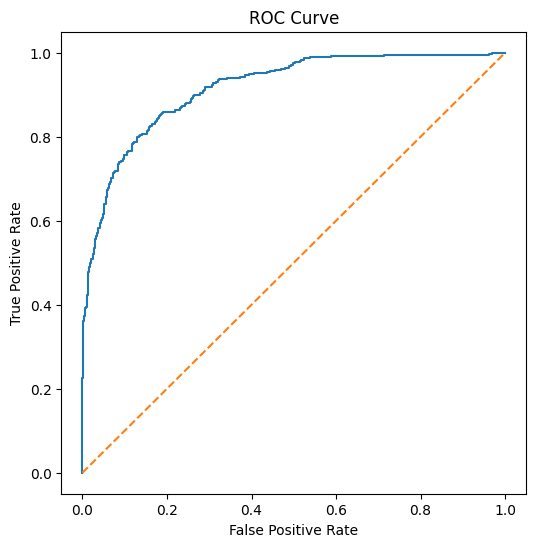

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [10]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4805, 28)
Test size: (1202, 28)


In [12]:
# =========================
# LOAD NEW DATA
# =========================

file_path = r"C:\Users\akshat\Downloads\prediction_data.xlsx"
sheet_name = 'vw_JoinData'

new_data = pd.read_excel(file_path, sheet_name=sheet_name)

print(new_data.head())

# Keep copy for final output
original_data = new_data.copy()

# =========================
# DROP UNUSED COLUMNS
# =========================

new_data = new_data.drop(
    columns=['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
    errors='ignore'
)

# =========================
# MAKE PREDICTIONS USING PIPELINE
# =========================

new_predictions = pipeline.predict(new_data)

# Add prediction column
original_data['Customer_Status_Predicted'] = new_predictions

# Optional: Map numeric back to label
original_data['Customer_Status_Predicted'] = original_data[
    'Customer_Status_Predicted'
].map({0: 'Stayed', 1: 'Churned'})

# =========================
# FILTER ONLY CHURNED
# =========================

churned_customers = original_data[
    original_data['Customer_Status_Predicted'] == 'Churned'
]

# =========================
# SAVE RESULTS
# =========================

churned_customers.to_csv(
    r"C:\Users\akshat\Downloads\Predictions.csv",
    index=False
)

print("Prediction file saved successfully.")

  Customer_ID  Gender  Age Married           State  Number_of_Referrals  \
0   16032-AND  Female   47      No  Andhra Pradesh                    8   
1   16068-BIH  Female   44     Yes           Bihar                    4   
2   16244-UTT  Female   19     Yes   Uttar Pradesh                    5   
3   16733-ODI  Female   76     Yes          Odisha                   10   
4   16764-WES    Male   40      No     West Bengal                   15   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                18        NaN           Yes             No  ...   
1                25     Deal 5            No             No  ...   
2                 7        NaN           Yes             No  ...   
3                 1        NaN           Yes             No  ...   
4                13     Deal 5           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal      46.599998     87.900002           0.0   
1  Bank Wi